# Vitara - Emotion to Stress Scoring (IndoTwitt Dataset)

## Background
Pengguna menulis jurnal harian yang mencerminkan kondisi emosional mereka. Data teks ini perlu diubah menjadi bentuk numerik agar dapat digunakan dalam sistem health scoring.

## Problem Statement
Bagaimana mengubah teks menjadi representasi numerik yang mencerminkan tingkat stress pengguna?

## Objective
Mengembangkan pipeline untuk mengubah label emosi menjadi stress score yang dapat digunakan dalam sistem AI.

## Business Questions

1. Bagaimana distribusi emosi dalam dataset?
2. Emosi apa yang paling sering muncul?
3. Bagaimana emosi dapat dikonversi menjadi stress score?
4. Bagaimana distribusi stress score setelah transformasi?


## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##Load Data

###Dataset Twitter

In [ ]:
df_twitter = pd.read_csv('/content/Twitter_Emotion_Dataset.csv', header=None, names=['Label', 'Tweet'], skiprows=1)
df_twitter = df_twitter[['Tweet', 'Label']]
df_twitter.head()

,Tweet,Label
0,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu...",anger
1,"Sesama cewe lho (kayaknya), harusnya bisa lebi...",anger
2,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...,happy
3,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng...",anger
4,"Sharing pengalaman aja, kemarin jam 18.00 bata...",happy


In [ ]:
df_twitter['Label'].value_counts()

,count
Label,
anger,1101
happy,1017
sadness,997
fear,649
love,637


###Dataset Emotion Public Opinion

In [ ]:
# !pip install datasets

In [ ]:
anger_url = 'https://raw.githubusercontent.com/Ricco48/Emotion-Dataset-from-Indonesian-Public-Opinion/refs/heads/main/Emotion%20Dataset%20from%20Indonesian%20Public%20Opinion/AngerData.csv'
fear_url = 'https://raw.githubusercontent.com/Ricco48/Emotion-Dataset-from-Indonesian-Public-Opinion/refs/heads/main/Emotion%20Dataset%20from%20Indonesian%20Public%20Opinion/FearData.csv'
joy_url = 'https://raw.githubusercontent.com/Ricco48/Emotion-Dataset-from-Indonesian-Public-Opinion/refs/heads/main/Emotion%20Dataset%20from%20Indonesian%20Public%20Opinion/JoyData.csv'
sad_url = 'https://raw.githubusercontent.com/Ricco48/Emotion-Dataset-from-Indonesian-Public-Opinion/refs/heads/main/Emotion%20Dataset%20from%20Indonesian%20Public%20Opinion/SadData.csv'
# love_url = 'https://raw.githubusercontent.com/Ricco48/Emotion-Dataset-from-Indonesian-Public-Opinion/refs/heads/main/Emotion%20Dataset%20from%20Indonesian%20Public%20Opinion/LoveData.csv'
neutral_url = 'https://raw.githubusercontent.com/Ricco48/Emotion-Dataset-from-Indonesian-Public-Opinion/refs/heads/main/Emotion%20Dataset%20from%20Indonesian%20Public%20Opinion/NeutralData.csv'

df_anger = pd.read_csv(anger_url, sep='\t')
df_fear = pd.read_csv(fear_url, sep='\t')
df_joy = pd.read_csv(joy_url, sep='\t')
df_sad = pd.read_csv(sad_url, sep='\t')
# df_love = pd.read_csv(love_url, sep='\t')
df_neutral = pd.read_csv(neutral_url, sep='\t')

In [ ]:
df_epo = pd.concat([df_anger, df_fear, df_joy, df_sad, df_neutral], ignore_index=True)
df_epo['Label'] = df_epo['Label'].str.lower()
df_epo.head()

,Tweet,Label
0,pagi2 udah di buat emosi :),anger
1,"kok stabilitas negara, memange 10 thn negara t...",anger
2,dah lah emosi mulu liat emyu,anger
3,"aib? bodoh benar! sebelum kata aib itu muncul,...",anger
4,dih lu yg nyebelin bego,anger


##Data Understanding

In [ ]:
print("Twitter shape:", df_twitter.shape)
print("Epo shape:", df_epo.shape)

Twitter shape: (4401, 2)
Epo shape: (6320, 2)


In [ ]:
print(df_twitter['Label'].value_counts())
print(df_epo['Label'].value_counts())

Label
anger      1101
happy      1017
sadness     997
fear        649
love        637
Name: count, dtype: int64
Label
neutral    2001
joy        1275
anger      1130
sad        1003
fear        911
Name: count, dtype: int64


##Data Cleaning

In [ ]:
df_twitter = df_twitter.dropna()
df_twitter = df_twitter.drop_duplicates()

In [ ]:
df_epo = df_epo.dropna()
df_epo = df_epo.drop_duplicates()

##Label Mapping

In [ ]:
twitter_map = {
    'happy': 'happy',
    'sadness': 'sad',
    'anger': 'angry',
    'fear': 'anxious'
}

df_twitter['emotion_label'] = df_twitter['Label'].map(twitter_map)

In [ ]:
epo_map = {
    'joy': 'happy',
    'love' : 'happy',
    'fear' : 'anxious',
    'neutral' : 'neutral',
    'sad' : 'sad',
    'anger' : 'angry'
}

df_epo['emotion_label'] = df_epo['Label'].map(epo_map)

In [ ]:
df_combined = pd.concat([df_twitter, df_epo], ignore_index=True)
df_combined.head()

,Tweet,Label,emotion_label
0,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu...",anger,angry
1,"Sesama cewe lho (kayaknya), harusnya bisa lebi...",anger,angry
2,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...,happy,happy
3,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng...",anger,angry
4,"Sharing pengalaman aja, kemarin jam 18.00 bata...",happy,happy


In [ ]:
df_combined = df_combined.dropna()
df_combined = df_combined.drop_duplicates()

In [ ]:
df_combined = df_combined.rename(columns={'Tweet': 'text', 'Label': 'label'})
df_combined.head()

,text,label,emotion_label
0,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu...",anger,angry
1,"Sesama cewe lho (kayaknya), harusnya bisa lebi...",anger,angry
2,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...,happy,happy
3,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng...",anger,angry
4,"Sharing pengalaman aja, kemarin jam 18.00 bata...",happy,happy


##EDA

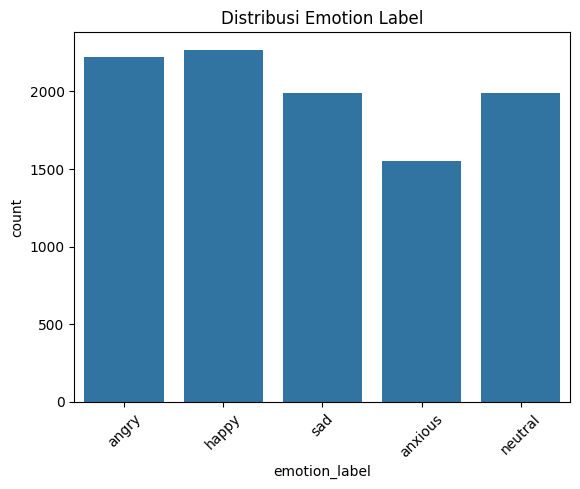

In [ ]:
sns.countplot(x='emotion_label', data=df_combined)
plt.title("Distribusi Emotion Label")
plt.xticks(rotation=45)
plt.show()

Insight:

- Dataset menunjukkan distribusi label yang cukup seimbang, sehingga model LSTM dapat belajar tiap kelas dengan relatif adil tanpa bias besar ke satu label
- Label happy dan angry paling dominan, sehingga model kemungkinan akan lebih mudah mengenali pola pada kedua emosi ini
- Label anxious paling sedikit, sehingga berpotensi menjadi kelas dengan performa terendah (recall rendah) saat evaluasi
- Karena distribusi tidak ekstrem, tidak diperlukan teknik balancing kompleks, namun tetap disarankan menggunakan stratified split saat train-test
- Visualisasi ini mengindikasikan bahwa evaluasi model tidak cukup hanya menggunakan akurasi, tetapi perlu classification report untuk melihat performa tiap label
- Dataset sudah cukup ideal untuk eksperimen LSTM, karena tidak ada class imbalance yang signifikan namun tetap memiliki variasi emosi yang jelas

##Feature Engineering

###Stress Scoring

In [ ]:
stress_range = {
    'happy': (0.0, 0.2),
    'neutral': (0.2, 0.4),
    'sad': (0.5, 0.8),
    'anxious': (0.7, 0.9),
    'angry': (0.85, 1.0)
}

In [ ]:
import random
import hashlib

def generate_stress_score(text, label):
    if label not in stress_range:
        return None

    low, high = stress_range[label]

    seed = int(hashlib.md5(text.encode()).hexdigest(), 16) % (10**8)
    random.seed(seed)

    score = random.uniform(low, high)
    return round(score, 2)

In [ ]:
df_combined['stress_label'] = df_combined.apply(
    lambda x: generate_stress_score(x['text'], x['emotion_label']),
    axis=1
)

In [ ]:
df_combined

,text,label,emotion_label,stress_label
0,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu...",anger,angry,0.96
1,"Sesama cewe lho (kayaknya), harusnya bisa lebi...",anger,angry,0.85
2,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...,happy,happy,0.16
3,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng...",anger,angry,0.88
4,"Sharing pengalaman aja, kemarin jam 18.00 bata...",happy,happy,0.01
...,...,...,...,...
10659,"karena tau rasa kesepian, manusia akan menjadi...",neutral,neutral,0.27
10660,yang terbaik adalah percaya dan berlindung han...,neutral,neutral,0.22
10661,sahabat adalah mereka yg tahu bahwa ada sedih ...,neutral,neutral,0.22
10662,"terkadang, bukan karena dusta, kamu membenci s...",neutral,neutral,0.29


###Impute Id & Language

In [ ]:
df_combined['id'] = ['jrn_' + str(i).zfill(3) for i in range(len(df_combined))]

In [ ]:
df_combined['language'] = 'id'

In [ ]:
df_combined = df_combined[['id', 'text', 'emotion_label', 'stress_label', 'language']]
df_combined.head()

,id,text,emotion_label,stress_label,language
0,jrn_000,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu...",angry,0.96,id
1,jrn_001,"Sesama cewe lho (kayaknya), harusnya bisa lebi...",angry,0.85,id
2,jrn_002,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...,happy,0.16,id
3,jrn_003,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng...",angry,0.88,id
4,jrn_004,"Sharing pengalaman aja, kemarin jam 18.00 bata...",happy,0.01,id


##Output Dataset

In [ ]:
df_combined.to_csv('journals.csv', index=False, encoding='utf-8')

## Data Dictionary

| Feature | Deskripsi |
|--------|----------|
| id | ID unik jurnal |
| text | teks jurnal pengguna |
| emotion_label | label emosi (happy, sad, anxious, angry, neutral) |
| stress_label | tingkat stres (0.0 - 1.0) |
| language | kode bahasa (id) |

##Conclusion

- Dataset hasil penggabungan berhasil mencakup 5 kategori emosi utama, yaitu happy, sad, anxious, angry, dan neutral.

- distribusi label pada dataset emosi menunjukkan kondisi yang relatif seimbang antar kelas, sehingga data sudah cukup ideal untuk digunakan dalam pelatihan model LSTM tanpa memerlukan penanganan imbalance yang kompleks

**REKOMENDASI UNTUK TIM AI:**

1. Dataset memiliki imbalance → disarankan:
   - class weighting
   - atau oversampling

2. Fokus evaluasi:
   - jangan hanya akurasi
   - gunakan F1-score per class

3. Perhatikan kelas:
   - anxious (minoritas)